Base geral tratada carregada com sucesso.
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
        Data  Sessões  Usuários ativos  Visualizações  dia_semana  \
0 2023-07-01     3109             2047           5566           6   
1 2023-07-02     3099             2083           5498           7   
2 2023-07-03    24119            13516          46786           1   
3 2023-07-04    23635            13335          44984           2   
4 2023-07-05    22217            13014          43559           3   

   fim_de_semana  mes  recesso_judiciario  feriado_nacional_fixo  carnaval  \
0              1    7                   0                      0         0   
1              1    7                   0                      0         0   
2              0    7                   0                      0         0   
3              0    7                   0                      0         0   
4              0    7                   0                      0         0   

   quarta_cinzas

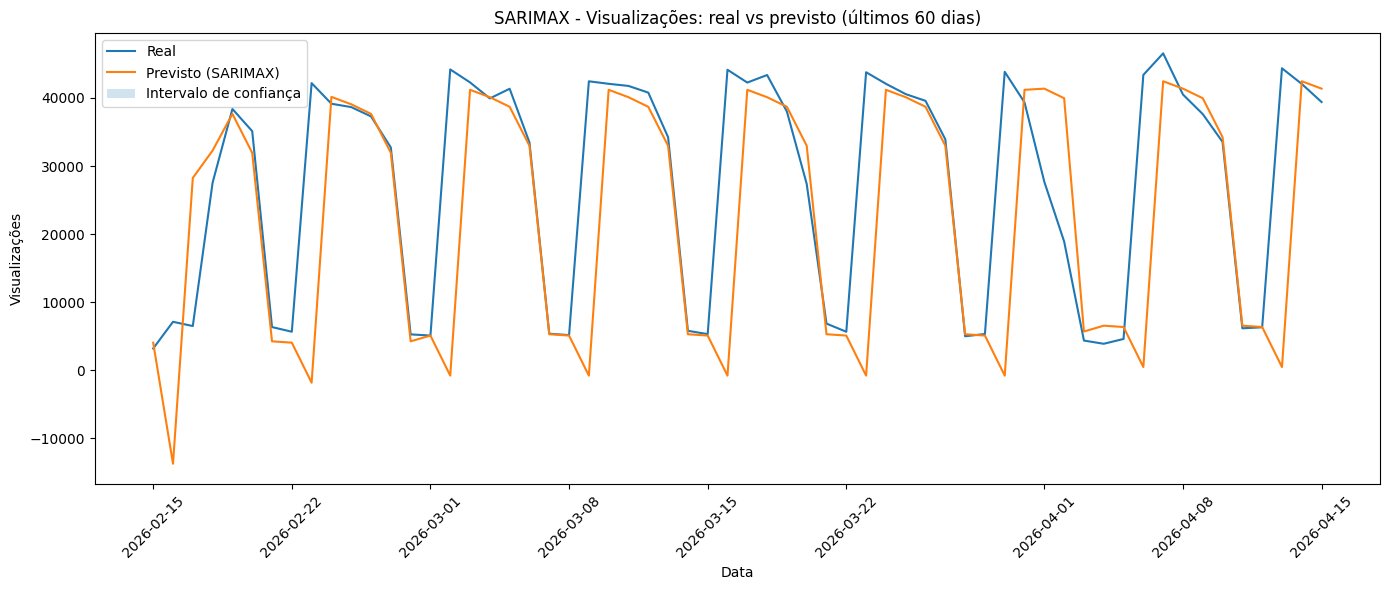

Arquivos salvos com sucesso:
../dados/metricas_sarimax.csv
../dados/previsao_sarimax_visualizacoes.csv
../dados/grid_sarimax.csv
../dados/resumo_sarimax.txt

Métricas do SARIMAX:
    modelo      ordem ordem_sazonal          rmse          mae       mape  \
0  SARIMAX  (0, 0, 1)  (1, 0, 1, 7)  16983.287783  8225.245354  34.081686   

         r2   aic  
0 -0.080808  40.0  

Primeiras previsões:
        Data   real  previsto_sarimax  ic_inferior  ic_superior          erro  \
0 2026-02-15   3182       4036.688996          NaN          NaN   -854.688996   
1 2026-02-16   7101     -13759.518482          NaN          NaN  20860.518482   
2 2026-02-17   6479      28249.982779          NaN          NaN -21770.982779   
3 2026-02-18  27554      32276.503951          NaN          NaN  -4722.503951   
4 2026-02-19  38385      37663.755334          NaN          NaN    721.244666   

   erro_absoluto  erro_percentual_abs  
0     854.688996            26.860119  
1   20860.518482           293.768744

In [1]:
# %% [markdown]
# ## 1. Geração da base específica para o SARIMAX
#
# Nesta etapa, a base geral tratada é carregada a partir do arquivo `trafego_tratado.csv`.
# O SARIMAX será ajustado com a série de `Visualizações` e variáveis externas conhecidas antecipadamente.
#
# As variáveis `Sessões` e `Usuários ativos` não foram utilizadas, pois seus valores futuros não seriam conhecidos em uma situação real de previsão.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

df = pd.read_csv("../dados/trafego_tratado.csv")

df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)

print("Base geral tratada carregada com sucesso.")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")
print(df.head())
print(df.info())


# %% [markdown]
# ## 2. Seleção da série e criação dos regressores externos
#
# Foram utilizados apenas regressores conhecidos antecipadamente, como atributos de calendário e funcionamento institucional.
# Para representar melhor o padrão semanal, a variável `dia_semana` foi convertida em variáveis dummies.
# A variável `fim_de_semana` não foi incluída separadamente, pois sua informação já está representada pelas dummies de dia da semana.

# %%
colunas_calendario = [
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_sarimax = df[[
    "Data",
    "Visualizações",
    "dia_semana",
    "mes"
] + colunas_calendario].copy()

# Dummies para dia da semana
dummies_dia = pd.get_dummies(
    df_sarimax["dia_semana"],
    prefix="dia_semana",
    drop_first=True,
    dtype=int
)

df_sarimax = pd.concat([df_sarimax, dummies_dia], axis=1)

# Representação cíclica do mês
df_sarimax["mes_sin"] = np.sin(2 * np.pi * df_sarimax["mes"] / 12)
df_sarimax["mes_cos"] = np.cos(2 * np.pi * df_sarimax["mes"] / 12)

df_sarimax = df_sarimax.drop(columns=["dia_semana", "mes"])

df_sarimax = df_sarimax.set_index("Data")
df_sarimax = df_sarimax.asfreq("D")

print("Valores ausentes por coluna:")
print(df_sarimax.isna().sum())

if df_sarimax.isna().sum().sum() > 0:
    raise ValueError("Há valores ausentes após definir frequência diária. Verifique a base.")

colunas_exog = [col for col in df_sarimax.columns if col != "Visualizações"]

print("\nRegressores externos utilizados:")
print(colunas_exog)

print("\nBase SARIMAX criada com sucesso.")
print(df_sarimax.head())
print(df_sarimax.info())


# %% [markdown]
# ## 3. Testes de estacionariedade
#
# Antes do ajuste do SARIMAX, foram aplicados testes de estacionariedade à série de `Visualizações`.
# O teste ADF tem como hipótese nula a presença de raiz unitária, enquanto o KPSS tem como hipótese nula a estacionariedade.
# Os resultados auxiliam na decisão de testar modelos com diferenciação.

# %%
serie = df_sarimax["Visualizações"].dropna()

adf_stat, adf_p, *_ = adfuller(serie)

try:
    kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
except Exception:
    kpss_stat, kpss_p = np.nan, np.nan

print("Teste ADF")
print(f"Estatística: {adf_stat:.4f}")
print(f"p-valor    : {adf_p:.4f}")

print("\nTeste KPSS")
print(f"Estatística: {kpss_stat:.4f}")
print(f"p-valor    : {kpss_p:.4f}")

print("\nInterpretação preliminar:")
if adf_p > 0.05:
    print("- ADF sugere possível não estacionariedade.")
else:
    print("- ADF sugere estacionariedade.")

if not np.isnan(kpss_p):
    if kpss_p < 0.05:
        print("- KPSS sugere possível não estacionariedade.")
    else:
        print("- KPSS sugere estacionariedade.")


# %% [markdown]
# ## 4. Separação temporal entre treino e teste
#
# Os últimos 60 dias foram reservados para teste. Os registros anteriores foram utilizados para treinamento.
# A separação foi feita sem embaralhamento, preservando a ordem temporal.

# %%
dias_teste = 60

y = df_sarimax["Visualizações"]
X = df_sarimax[colunas_exog]

y_train = y.iloc[:-dias_teste]
y_test = y.iloc[-dias_teste:]

X_train = X.iloc[:-dias_teste]
X_test = X.iloc[-dias_teste:]

assert X_train.isna().sum().sum() == 0, "X_train contém valores ausentes."
assert X_test.isna().sum().sum() == 0, "X_test contém valores ausentes."
assert y_train.isna().sum() == 0, "y_train contém valores ausentes."
assert y_test.isna().sum() == 0, "y_test contém valores ausentes."

print("Separação treino/teste realizada com sucesso.")
print(f"Registros de treino: {len(y_train)}")
print(f"Registros de teste : {len(y_test)}")
print(f"Período de teste: {y_test.index.min().date()} a {y_test.index.max().date()}")


# %% [markdown]
# ## 5. Busca ampliada de parâmetros SARIMAX
#
# Foi realizada uma busca ampliada de combinações de parâmetros, incluindo diferenciação simples e sazonal.
# A seleção preliminar foi feita pelo menor AIC, considerando modelos com sazonalidade semanal.

# %%
p_values = [0, 1, 2, 3, 7]
d_values = [0, 1]
q_values = [0, 1, 2, 3, 7]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 7

resultados_grid = []

melhor_aic = np.inf
melhor_ordem = None
melhor_ordem_sazonal = None
melhor_modelo = None

total_testes = 0

for p in p_values:
    for d in d_values:
        for q in q_values:
            ordem = (p, d, q)

            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        ordem_sazonal = (P, D, Q, s)
                        total_testes += 1

                        try:
                            modelo = SARIMAX(
                                y_train,
                                exog=X_train,
                                order=ordem,
                                seasonal_order=ordem_sazonal,
                                enforce_stationarity=True,
                                enforce_invertibility=True
                            )

                            resultado = modelo.fit(disp=False, maxiter=300)

                            resultados_grid.append({
                                "ordem": ordem,
                                "ordem_sazonal": ordem_sazonal,
                                "aic": resultado.aic,
                                "bic": resultado.bic,
                                "convergiu": resultado.mle_retvals.get("converged", None)
                            })

                            if resultado.aic < melhor_aic:
                                melhor_aic = resultado.aic
                                melhor_ordem = ordem
                                melhor_ordem_sazonal = ordem_sazonal
                                melhor_modelo = resultado

                            print(f"OK | ordem={ordem} | sazonal={ordem_sazonal} | AIC={resultado.aic:.2f}")

                        except Exception as e:
                            resultados_grid.append({
                                "ordem": ordem,
                                "ordem_sazonal": ordem_sazonal,
                                "aic": np.nan,
                                "bic": np.nan,
                                "convergiu": False,
                                "erro": str(e)
                            })

                            print(f"ERRO | ordem={ordem} | sazonal={ordem_sazonal}")

df_grid_sarimax = pd.DataFrame(resultados_grid)
df_grid_sarimax.to_csv("../dados/grid_sarimax.csv", index=False)

print("\nBusca concluída.")
print(f"Total de combinações testadas: {total_testes}")
print("\nMelhor configuração encontrada:")
print(f"Ordem: {melhor_ordem}")
print(f"Ordem sazonal: {melhor_ordem_sazonal}")
print(f"AIC: {melhor_aic:.2f}")

print("\nTop 10 modelos por AIC:")
print(df_grid_sarimax.dropna(subset=["aic"]).sort_values("aic").head(10))


# %% [markdown]
# ## 6. Diagnóstico básico do modelo selecionado
#
# Após a seleção do modelo, foram verificadas informações básicas do ajuste, incluindo o resumo estatístico e as raízes AR e MA.
# Essa etapa ajuda a identificar possíveis problemas de estabilidade ou invertibilidade.

# %%
if melhor_modelo is None:
    raise ValueError("Nenhum modelo SARIMAX foi ajustado com sucesso.")

print(melhor_modelo.summary())

with open("../dados/resumo_sarimax.txt", "w", encoding="utf-8") as f:
    f.write(str(melhor_modelo.summary()))

try:
    ar_roots_abs = np.abs(melhor_modelo.arroots)
    ma_roots_abs = np.abs(melhor_modelo.maroots)

    print("\nRaízes AR - módulo:")
    print(ar_roots_abs)

    print("\nRaízes MA - módulo:")
    print(ma_roots_abs)

    if len(ar_roots_abs) > 0:
        print(f"\nMenor módulo das raízes AR: {ar_roots_abs.min():.4f}")
    if len(ma_roots_abs) > 0:
        print(f"Menor módulo das raízes MA: {ma_roots_abs.min():.4f}")

except Exception as e:
    print(f"Não foi possível calcular raízes AR/MA: {e}")


# %% [markdown]
# ## 7. Previsão no conjunto de teste
#
# O modelo selecionado foi utilizado para prever os últimos 60 dias da série.
# Como o SARIMAX utiliza regressores externos, foram fornecidas ao modelo as variáveis de calendário correspondentes ao período de teste.

# %%
assert X_test.isna().sum().sum() == 0, "X_test contém valores ausentes."

previsao_sarimax = melhor_modelo.get_forecast(
    steps=dias_teste,
    exog=X_test
)

y_pred_sarimax = previsao_sarimax.predicted_mean
intervalo_conf = previsao_sarimax.conf_int()

print("Previsão SARIMAX realizada com sucesso.")
print(y_pred_sarimax.head())
print(intervalo_conf.head())


# %% [markdown]
# ## 8. Avaliação do SARIMAX
#
# O desempenho do SARIMAX foi avaliado pelas métricas RMSE, MAE, MAPE e R².
# No cálculo do MAPE, dias com valor real igual a zero são excluídos, quando existirem, para evitar divisão por zero.

# %%
def calcular_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    zeros = np.sum(y_true == 0)
    if zeros > 0:
        print(f"Atenção: {zeros} observações com valor real zero foram excluídas do cálculo do MAPE.")

    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100


rmse_sarimax = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)
mape_sarimax = calcular_mape(y_test, y_pred_sarimax)
r2_sarimax = r2_score(y_test, y_pred_sarimax)

print("=" * 60)
print("AVALIAÇÃO SARIMAX - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"Ordem: {melhor_ordem}")
print(f"Ordem sazonal: {melhor_ordem_sazonal}")
print(f"RMSE: {rmse_sarimax:.2f}")
print(f"MAE : {mae_sarimax:.2f}")
print(f"MAPE: {mape_sarimax:.2f}%")
print(f"R²  : {r2_sarimax:.4f}")


# %% [markdown]
# ## 9. Visualização dos valores reais e previstos pelo SARIMAX

# %%
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, y_pred_sarimax.values, label="Previsto (SARIMAX)")

plt.fill_between(
    y_test.index,
    intervalo_conf.iloc[:, 0],
    intervalo_conf.iloc[:, 1],
    alpha=0.2,
    label="Intervalo de confiança"
)

plt.title("SARIMAX - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# %% [markdown]
# ## 10. Salvamento das métricas, previsões e intervalos de confiança
#
# Ao final da execução, foram salvas as métricas de desempenho, as previsões e os intervalos de confiança gerados pelo SARIMAX.

# %%
metricas_sarimax = pd.DataFrame({
    "modelo": ["SARIMAX"],
    "ordem": [str(melhor_ordem)],
    "ordem_sazonal": [str(melhor_ordem_sazonal)],
    "rmse": [rmse_sarimax],
    "mae": [mae_sarimax],
    "mape": [mape_sarimax],
    "r2": [r2_sarimax],
    "aic": [melhor_aic]
})

metricas_sarimax.to_csv("../dados/metricas_sarimax.csv", index=False)

previsao_sarimax_df = pd.DataFrame({
    "Data": y_test.index,
    "real": y_test.values,
    "previsto_sarimax": y_pred_sarimax.values,
    "ic_inferior": intervalo_conf.iloc[:, 0].values,
    "ic_superior": intervalo_conf.iloc[:, 1].values
})

previsao_sarimax_df["erro"] = (
    previsao_sarimax_df["real"] - previsao_sarimax_df["previsto_sarimax"]
)

previsao_sarimax_df["erro_absoluto"] = abs(previsao_sarimax_df["erro"])

previsao_sarimax_df["erro_percentual_abs"] = (
    previsao_sarimax_df["erro_absoluto"] / previsao_sarimax_df["real"]
) * 100

previsao_sarimax_df.to_csv("../dados/previsao_sarimax_visualizacoes.csv", index=False)

print("Arquivos salvos com sucesso:")
print("../dados/metricas_sarimax.csv")
print("../dados/previsao_sarimax_visualizacoes.csv")
print("../dados/grid_sarimax.csv")
print("../dados/resumo_sarimax.txt")

print("\nMétricas do SARIMAX:")
print(metricas_sarimax)

print("\nPrimeiras previsões:")
print(previsao_sarimax_df.head())